# Projeto Final — Análise Exploratória de Dados (Olist)

## 1. Apresentação da Base e Perguntas de Negócio
### 1.1. Origem dos Dados
Os dados foram extraídos do dataset público do **Olist** no Kaggle, cobrindo o e-commerce brasileiro.

### 1.2. Perguntas de Negócio
1. **Prazos e Frete:** Qual a relação entre o custo do frete e o tempo real de entrega entre os diferentes estados?
2. **Meios de Pagamento e Ticket:** Como o valor médio do pedido varia em função do tipo de pagamento e do parcelamento?
3. **Outliers de Frete:** Quais estados apresentam os maiores outliers de valor de frete em relação ao preço das mercadorias?
4. **Recorrência:** Clientes recorrentes possuem comportamento de compra diferente dos clientes pontuais?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura das bases de dados (existentes + novas)
df_customers = pd.read_csv('../dados/olist_customers_dataset.csv')
df_orders = pd.read_csv('../dados/olist_orders_dataset.csv')
df_items = pd.read_csv('../dados/olist_order_items_dataset.csv')

df_payments = pd.read_csv('../dados/olist_order_payments_dataset.csv')

# Bases adicionais
df_reviews = pd.read_csv('../dados/olist_order_reviews_dataset.csv')

df_products = pd.read_csv('../dados/olist_products_dataset.csv')
df_categories = pd.read_csv('../dados/product_category_name_translation.csv')

print("Todas as 7 bases foram carregadas com sucesso!")

Todas as 7 bases foram carregadas com sucesso!


## 2. Estrutura e Granularidade das Bases
Antes de realizar os cruzamentos entre as tabelas, vamos verificar a estrutura e a granularidade de cada base. Isso é importante porque uma mesma informação pode aparecer várias vezes em algumas tabelas. Por exemplo, um pedido pode possuir vários itens e também vários pagamentos. Portanto, em vez de criar um único DataFrame com todas as tabelas, construiremos DataFrames específicos de acordo com cada pergunta de negócio, evitando a duplicação de registros e a distorção das métricas.

In [3]:
# Tradução das categorias dos produtos
df_products = df_products.merge(
    df_categories,
    on='product_category_name',
    how='left'
)

print("Categorias dos produtos traduzidas.")

Categorias dos produtos traduzidas.


### 2.1. Verificação da estrutura das bases

Primeiro, vamos verificar a quantidade de linhas e colunas de cada tabela. Essa informação ajuda a identificar o tamanho das bases e, principalmente, perceber que elas possuem diferentes níveis de granularidade.

In [4]:
print("orders:", df_orders.shape)
print("customers:", df_customers.shape)
print("items:", df_items.shape)
print("payments:", df_payments.shape)
print("products:", df_products.shape)
print("reviews:", df_reviews.shape)
print("categories:", df_categories.shape)

orders: (99441, 8)
customers: (99441, 5)
items: (112650, 7)
payments: (103886, 5)
products: (32951, 10)
reviews: (99224, 7)
categories: (71, 2)


### 2.2. Verificação da granularidade

Agora vamos verificar se order_id é único em cada tabela. Em orders, esperamos um registro por pedido. Já em items e payments, um mesmo pedido pode aparecer várias vezes, pois um pedido pode conter vários itens e pode possuir mais de um pagamento.

In [5]:
print("order_id único em orders:",
      df_orders['order_id'].is_unique)

print("order_id único em items:",
      df_items['order_id'].is_unique)

print("order_id único em payments:",
      df_payments['order_id'].is_unique)

order_id único em orders: True
order_id único em items: False
order_id único em payments: False


Interpretação: A tabela orders possui um registro único para cada pedido. Já items e payments possuem múltiplos registros para um mesmo order_id. Por isso, juntar essas tabelas diretamente poderia multiplicar registros quando um pedido possui vários itens e vários pagamentos. Para evitar esse problema, as tabelas serão combinadas de acordo com a necessidade de cada análise.

### 2.3. Construção dos DataFrames para análise

Como as tabelas possuem diferentes níveis de granularidade, não utilizaremos um único DataFrame com todas as informações.

Os cruzamentos serão realizados de acordo com cada pergunta de negócio, preservando a granularidade adequada para cada análise.

#### 2.3.1. Pedidos e clientes

Primeiro, vamos relacionar os pedidos aos seus respectivos clientes.

A tabela `orders` possui um registro por pedido e `customers` possui as informações do cliente associado ao pedido. Portanto, esperamos uma relação de um para um entre essas duas tabelas por `customer_id`.

In [6]:
df_orders_customers = df_orders.merge(
    df_customers,
    on='customer_id',
    how='left',
    validate='one_to_one'
)

print("Orders:", df_orders.shape)
print("Orders + Customers:", df_orders_customers.shape)

Orders: (99441, 8)
Orders + Customers: (99441, 12)


**Interpretação:** O primeiro cruzamento entre `orders` e `customers` manteve as 99.441 linhas da tabela de pedidos. Isso confirma que o relacionamento utilizado preservou a granularidade de um registro por pedido.

#### 2.3.2. Pedidos, clientes e itens

Agora adicionaremos os itens dos pedidos. Diferentemente da relação anterior, um pedido pode possuir vários itens. Portanto, esperamos uma relação de um para muitos (`one-to-many`).

Após esse cruzamento, a granularidade do DataFrame passa de **um registro por pedido** para **um registro por item do pedido**.

In [7]:
df_entrega = df_orders_customers.merge(
    df_items,
    on='order_id',
    how='left',
    validate='one_to_many'
)

print("Orders + Customers:", df_orders_customers.shape)
print("Orders + Customers + Items:", df_entrega.shape)

Orders + Customers: (99441, 12)
Orders + Customers + Items: (113425, 18)


**Interpretação:** Após adicionar a tabela `items`, o número de registros aumentou de 99.441 para 113.425. Isso ocorre porque um mesmo pedido pode conter vários itens. Portanto, o DataFrame `df_entrega` passa a ter como granularidade um registro por item do pedido, e não mais um registro por pedido.

In [8]:
df_entrega[['order_id', 'product_id', 'price', 'freight_value']].head(10)

,order_id,product_id,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72
5,a4591c265e18cb1dcee52889e2d8acc3,060cb19345d90064d1015407193c233d,147.90,27.36
6,136cce7faa42fdb2cefd53fdc79a6098,a1804276d9941ac0733cfd409f5206eb,49.90,16.05
7,6514b8ad8028c9f2cc2374ded245783f,4520766ec412348b8d4caa5e8a18c464,59.99,15.17
8,76c6e866289321a7c93b82b54852dc33,ac1789e492dcd698c5c10b97a671243a,19.90,16.05
9,e69bfb5eb88e0ed6a785585b27e16dbf,9a78fb9862b10749a117f7fc3c31f051,149.99,19.77


### Verificação de um pedido com múltiplos itens

Para visualizar na prática a mudança de granularidade, vamos identificar um pedido que possui vários itens e observar como ele aparece no DataFrame após o cruzamento.

In [9]:
pedido_exemplo = (
    df_entrega.groupby('order_id')
    .size()
    .sort_values(ascending=False)
    .index[0]
)

print("Pedido escolhido:", pedido_exemplo)

df_entrega[
    df_entrega['order_id'] == pedido_exemplo
][['order_id', 'product_id', 'price', 'freight_value']]

Pedido escolhido: 8272b63d03f5f79c56e9e4120aec44ef


,order_id,product_id,price,freight_value
101222,8272b63d03f5f79c56e9e4120aec44ef,270516a3f41dc035aa87d220228f844c,1.2,7.89
101223,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101224,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101225,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101226,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101227,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101228,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101229,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101230,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89
101231,8272b63d03f5f79c56e9e4120aec44ef,05b515fdc76e888aada3c6d66c201dff,1.2,7.89


#### 2.3.3. Itens e produtos

Para complementar as informações dos itens, vamos relacioná-los aos dados dos produtos por meio de `product_id`.

A tabela `order_items` pode possuir vários registros para o mesmo produto, pois um produto pode ser vendido em diferentes pedidos. Já a tabela `products` possui um registro por produto.

Portanto, esperamos uma relação de muitos para um (`many-to-one`).

In [10]:
df_itens_produtos = df_items.merge(
    df_products,
    on='product_id',
    how='left',
    validate='many_to_one'
)

print("Items:", df_items.shape)
print("Items + Products:", df_itens_produtos.shape)

Items: (112650, 7)
Items + Products: (112650, 16)


O cruzamento manteve a quantidade de registros porque cada item está associado a um único produto. A relação `many-to-one` foi validada com sucesso.

## 3. Diagnóstico da Qualidade dos Dados

Antes de realizar as análises, vamos verificar a qualidade e a estrutura dos dados utilizados.

Como cada pergunta de negócio utiliza DataFrames com diferentes granularidades, o diagnóstico será realizado considerando a base correspondente a cada análise.

Nesta primeira etapa, vamos analisar o `df_entrega`, utilizado nas análises relacionadas a prazo, frete e estado.

### 3.1. Dimensões, tipos e uso de memória

In [11]:
df_entrega.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  113425 non-null  str    
 8   customer_unique_id             113425 non-null  str    
 9   customer_zip_code_prefix       113425 non-null  int64  
 10  customer_city                  113425 non-null  str    
 11  customer_state                 113425 non-null  str    
 12  order_item_id                  112650 non

**Interpretação:** O DataFrame `df_entrega` possui 113.425 registros e 18 colunas, com aproximadamente 15,6 MB de uso de memória. A maior parte das colunas está no formato `object`, incluindo as datas, que posteriormente poderão ser convertidas para o formato `datetime` para permitir cálculos relacionados a prazos de entrega.

Também foram identificados valores ausentes em algumas colunas, principalmente nas informações relacionadas à aprovação e às datas de entrega. Esses valores serão investigados na próxima etapa do diagnóstico antes de definir qualquer estratégia de tratamento.

### 3.2. Valores ausentes

In [12]:
missing = pd.DataFrame({
    'quantidade': df_entrega.isna().sum(),
    'percentual': (df_entrega.isna().mean() * 100).round(2)
})

missing = missing[missing['quantidade'] > 0].sort_values(
    'percentual',
    ascending=False
)

missing

,quantidade,percentual
order_delivered_customer_date,3229,2.85
order_delivered_carrier_date,1968,1.74
order_item_id,775,0.68
product_id,775,0.68
seller_id,775,0.68
shipping_limit_date,775,0.68
price,775,0.68
freight_value,775,0.68
order_approved_at,161,0.14


#### 3.2.1. Investigação dos valores ausentes em order_items

As colunas relacionadas aos itens apresentam exatamente a mesma quantidade de valores ausentes. Vamos verificar se esses registros correspondem a pedidos que não possuem informações na tabela `order_items`.

Essa verificação é importante para diferenciar valores ausentes originados nos dados de origem daqueles que surgiram como consequência do cruzamento entre as tabelas.

In [13]:
colunas_items = [
    'order_item_id',
    'product_id',
    'seller_id',
    'shipping_limit_date',
    'price',
    'freight_value'
]

df_entrega[df_entrega['order_item_id'].isna()][colunas_items].head()

,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
306,NaN,NaN,NaN,NaN,NaN,NaN
671,NaN,NaN,NaN,NaN,NaN,NaN
791,NaN,NaN,NaN,NaN,NaN,NaN
850,NaN,NaN,NaN,NaN,NaN,NaN
1294,NaN,NaN,NaN,NaN,NaN,NaN


#### 3.2.2. Investigação dos valores ausentes nas datas do pedido

As datas relacionadas ao processo de entrega apresentam valores ausentes em diferentes proporções. Antes de definir qualquer tratamento, vamos verificar a situação dos pedidos e identificar se os valores ausentes estão relacionados ao status do pedido.

In [14]:
df_entrega['order_status'].value_counts(dropna=False)

order_status
delivered      110197
shipped          1186
canceled          706
unavailable       610
invoiced          361
processing        357
created             5
approved            3
Name: count, dtype: int64

#### 3.2.3. Relação entre status do pedido e datas ausentes

Como `df_entrega` possui granularidade de item, a análise das datas e do status será realizada utilizando `df_orders_customers`, que possui uma linha por pedido.

Dessa forma, cada pedido será contabilizado uma única vez, evitando que pedidos com vários itens tenham peso maior no diagnóstico.

In [15]:
status_datas = df_orders_customers.groupby('order_status').agg(
    total_pedidos=('order_id', 'count'),
    sem_data_transportadora=('order_delivered_carrier_date', lambda x: x.isna().sum()),
    sem_data_entrega=('order_delivered_customer_date', lambda x: x.isna().sum())
)

status_datas

,total_pedidos,sem_data_transportadora,sem_data_entrega
order_status,,,
approved,2,2,2
canceled,625,550,619
created,5,5,5
delivered,96478,2,8
invoiced,314,314,314
processing,301,301,301
shipped,1107,0,1107
unavailable,609,609,609


#### 3.2.4. Investigação dos pedidos entregues sem data de entrega

Embora a maioria dos pedidos com status `delivered` possua as datas de entrega preenchidas, foram identificados 8 pedidos sem `order_delivered_customer_date`.

Vamos verificar esses registros antes de definir o tratamento, pois eles não poderão ser utilizados no cálculo do prazo real de entrega enquanto a data estiver ausente.

In [16]:
df_orders_customers[
    (df_orders_customers['order_status'] == 'delivered') &
    (df_orders_customers['order_delivered_customer_date'].isna())
][[
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


**Interpretação:** Foram identificados 8 pedidos com status `delivered` que não possuem a data efetiva de entrega ao cliente. Como essa informação não pode ser determinada de forma confiável a partir dos dados disponíveis, esses valores não serão preenchidos artificialmente.

Para a análise de prazo real de entrega, serão considerados posteriormente apenas os pedidos que possuam as datas necessárias para o cálculo. Dessa forma, preservamos os dados originais e evitamos introduzir informações estimadas sem justificativa.

### 3.3. Registros duplicados

Como `df_orders_customers` possui uma linha por pedido, vamos verificar se existem registros completamente duplicados nessa base.

Essa verificação é importante para identificar possíveis repetições dos mesmos registros antes das etapas de transformação e análise.

In [17]:
duplicados_orders = df_orders_customers.duplicated().sum()

print("Registros duplicados:", duplicados_orders)

Registros duplicados: 0


**Interpretação:** Não foram identificados registros completamente duplicados em `df_orders_customers`. Portanto, não será necessário realizar uma remoção de duplicidades nessa base.

### 3.4. Verificação de categorias inconsistentes

Vamos verificar as categorias existentes em `order_status` para identificar possíveis diferenças de grafia, espaços ou outras inconsistências que possam representar a mesma categoria.

In [18]:
df_orders_customers['order_status'].value_counts(dropna=False)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

**Interpretação:** As categorias de `order_status` apresentam nomenclatura padronizada, sem diferenças aparentes de grafia, capitalização ou espaços que indiquem categorias duplicadas. Portanto, não é necessário realizar tratamento de padronização nessa variável.

#### 3.4.1. Verificação das categorias de estado

Como o estado do cliente será utilizado nas análises de frete e prazo, vamos verificar as categorias presentes em `customer_state` e identificar possíveis valores inconsistentes.

In [19]:
df_orders_customers['customer_state'].value_counts(dropna=False)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

#### 3.4.2. Verificação de espaços e caps

Além da inspeção das categorias, vamos verificar se existem valores que seriam alterados ao remover espaços ou padronizar as letras para maiúsculas.

In [20]:
estados_inconsistentes = df_orders_customers[
    df_orders_customers['customer_state'] !=
    df_orders_customers['customer_state'].str.strip().str.upper()
][['customer_state']]

estados_inconsistentes.drop_duplicates()

,customer_state


### 3.5. Verificação de valores inválidos

Nesta etapa, vamos verificar se existem valores numéricos que não são compatíveis com o significado das variáveis utilizadas na análise.

Como `price` representa o preço do item e `freight_value` representa o valor do frete, valores negativos seriam inconsistentes com essas definições.

In [21]:
valores_invalidos = {
    'price_negativo': (df_entrega['price'] < 0).sum(),
    'freight_negativo': (df_entrega['freight_value'] < 0).sum()
}

pd.Series(valores_invalidos)

price_negativo      0
freight_negativo    0
dtype: int64

**Interpretação:** Não foram identificados valores negativos nas variáveis `price` e `freight_value`. Portanto, não foi identificado, nesta verificação, nenhum valor incompatível com o significado dessas variáveis.

### 3.6. Identificação de Outliers


 📊 ANÁLISE DE DIAGNÓSTICO E OUTLIERS: df_orders_customers

🔹 Variável: 'customer_zip_code_prefix' (Total registros: 99,441)
   • Média (NumPy): 35137.47 | Desvio Padrão: 29797.79
   • Outliers IQR (Limites: [-59982.50, 130229.50]): 0 (0.00%)
   • Outliers Z-Score (|Z| > 3): 0 (0.00%)


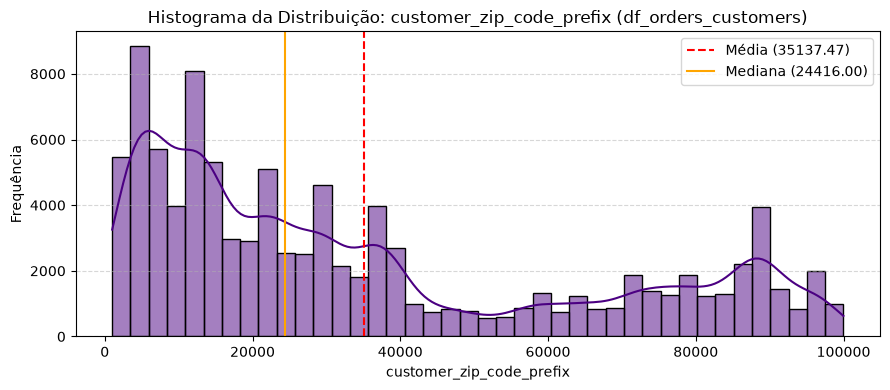


 📊 ANÁLISE DE DIAGNÓSTICO E OUTLIERS: df_items

🔹 Variável: 'price' (Total registros: 112,650)
   • Média (NumPy): 120.65 | Desvio Padrão: 183.63
   • Outliers IQR (Limites: [-102.60, 277.40]): 8,427 (7.48%)
   • Outliers Z-Score (|Z| > 3): 1,966 (1.75%)


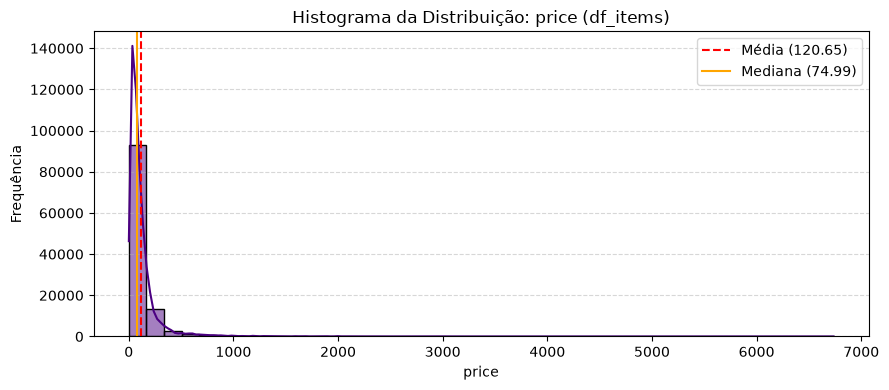


🔹 Variável: 'freight_value' (Total registros: 112,650)
   • Média (NumPy): 19.99 | Desvio Padrão: 15.81
   • Outliers IQR (Limites: [0.98, 33.25]): 12,134 (10.77%)
   • Outliers Z-Score (|Z| > 3): 2,041 (1.81%)


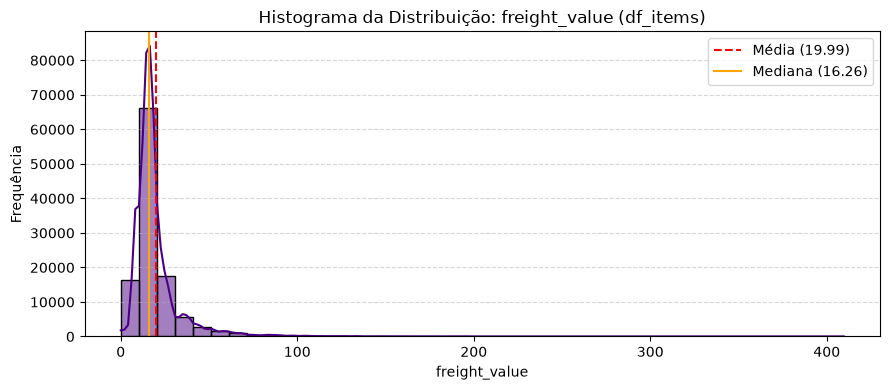


 📊 ANÁLISE DE DIAGNÓSTICO E OUTLIERS: df_payments

🔹 Variável: 'payment_sequential' (Total registros: 103,886)
   • Média (NumPy): 1.09 | Desvio Padrão: 0.71
   • Outliers IQR (Limites: [1.00, 1.00]): 4,526 (4.36%)
   • Outliers Z-Score (|Z| > 3): 906 (0.87%)


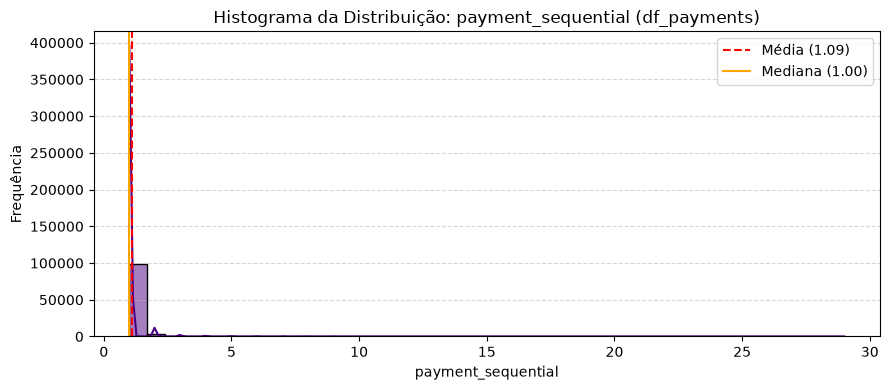


🔹 Variável: 'payment_installments' (Total registros: 103,886)
   • Média (NumPy): 2.85 | Desvio Padrão: 2.69
   • Outliers IQR (Limites: [-3.50, 8.50]): 6,313 (6.08%)
   • Outliers Z-Score (|Z| > 3): 341 (0.33%)


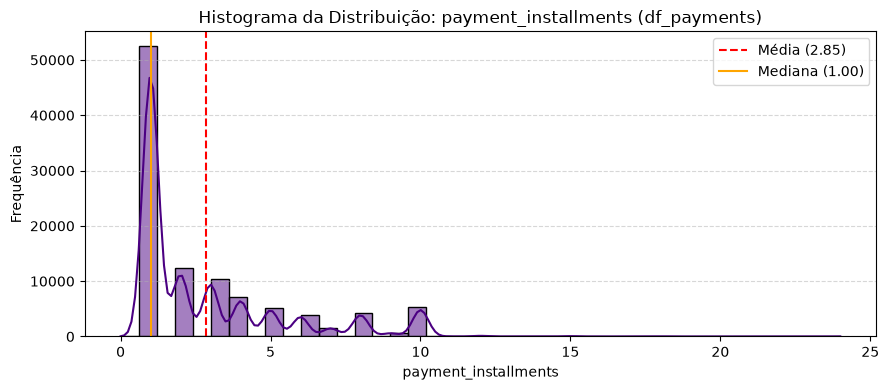


🔹 Variável: 'payment_value' (Total registros: 103,886)
   • Média (NumPy): 154.10 | Desvio Padrão: 217.49
   • Outliers IQR (Limites: [-115.78, 344.41]): 7,981 (7.68%)
   • Outliers Z-Score (|Z| > 3): 1,803 (1.74%)


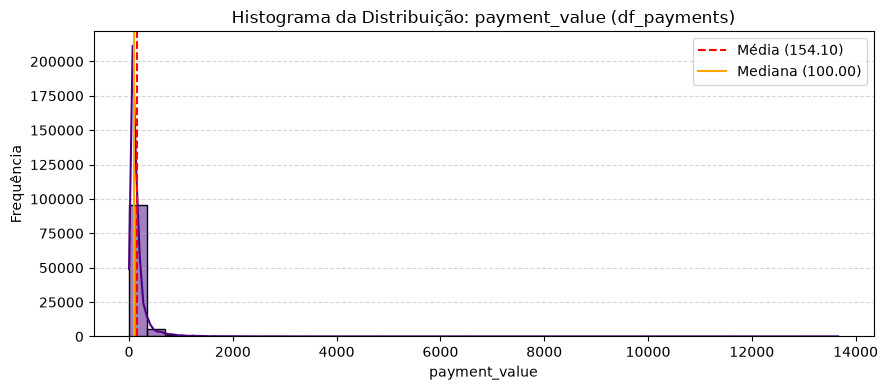


 📊 ANÁLISE DE DIAGNÓSTICO E OUTLIERS: df_entrega

🔹 Variável: 'customer_zip_code_prefix' (Total registros: 113,425)
   • Média (NumPy): 35102.47 | Desvio Padrão: 29864.79
   • Outliers IQR (Limites: [-60405.00, 130675.00]): 0 (0.00%)
   • Outliers Z-Score (|Z| > 3): 0 (0.00%)


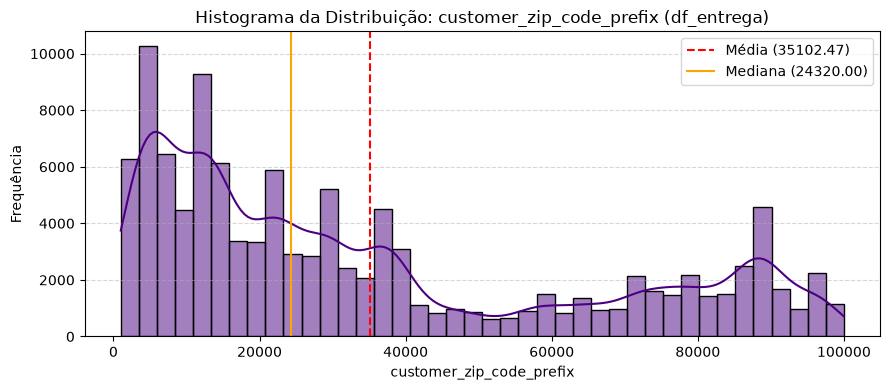


🔹 Variável: 'price' (Total registros: 112,650)
   • Média (NumPy): 120.65 | Desvio Padrão: 183.63
   • Outliers IQR (Limites: [-102.60, 277.40]): 8,427 (7.48%)
   • Outliers Z-Score (|Z| > 3): 1,966 (1.75%)


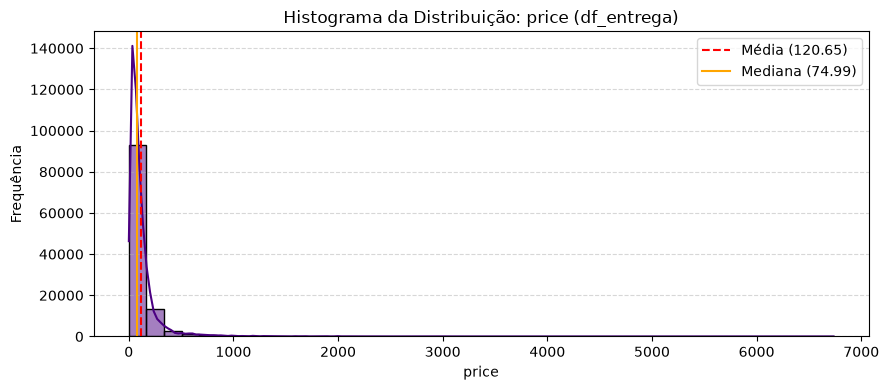


🔹 Variável: 'freight_value' (Total registros: 112,650)
   • Média (NumPy): 19.99 | Desvio Padrão: 15.81
   • Outliers IQR (Limites: [0.98, 33.25]): 12,134 (10.77%)
   • Outliers Z-Score (|Z| > 3): 2,041 (1.81%)


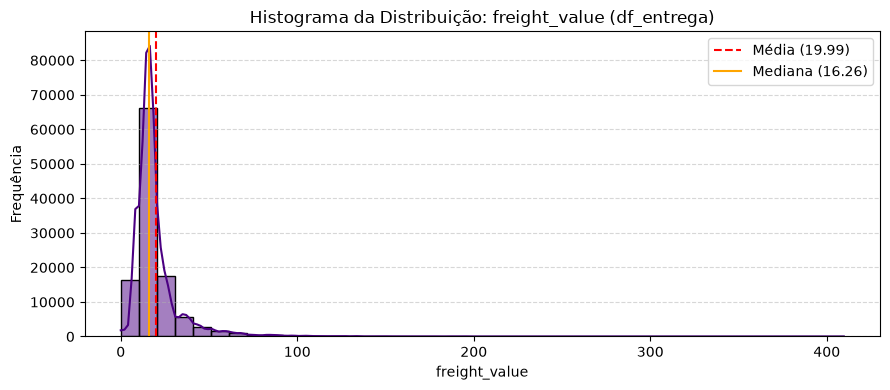

In [25]:
# ==============================================================================
# DIAGNÓSTICO DE OUTLIERS E DISTRIBUIÇÕES PARA TODOS OS DATAFRAMES
# Métodos: IQR, Z-Score (NumPy) e Histogramas
# ==============================================================================

# Dicionário mapeando os DataFrames principais do grupo
dataframes_projeto = {
    'df_orders_customers': df_orders_customers,
    'df_items': df_items,
    'df_payments': df_payments,
    'df_entrega': df_entrega
}

# Loop para aplicar a análise de diagnósticos em cada DataFrame
for nome_df, df_atual in dataframes_projeto.items():
    print(f"\n==================================================================")
    print(f" 📊 ANÁLISE DE DIAGNÓSTICO E OUTLIERS: {nome_df}")
    print(f"==================================================================")
    
    # Seleciona apenas colunas numéricas contínuas (exclui IDs)
    colunas_num = df_atual.select_dtypes(include=[np.number]).columns
    colunas_num = [c for c in colunas_num if not c.endswith('_id') and c != 'order_item_id']
    
    if len(colunas_num) == 0:
        print(f"Nenhuma coluna numérica contínua encontrada em {nome_df}.\n")
        continue

    for col in colunas_num:
        dados = df_atual[col].dropna()
        
        # 1. Cálculo do IQR
        q1 = dados.quantile(0.25)
        q3 = dados.quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        
        outliers_iqr = (dados < lim_inf) | (dados > lim_sup)
        qtd_iqr = outliers_iqr.sum()
        pct_iqr = (qtd_iqr / len(dados)) * 100
        
        # 2. Cálculo do Z-Score com NumPy
        vetor_dados = dados.values
        media_np = np.mean(vetor_dados)
        desvio_np = np.std(vetor_dados)
        
        if desvio_np > 0:
            z_scores = (vetor_dados - media_np) / desvio_np
            outliers_z = np.abs(z_scores) > 3
            qtd_z = np.sum(outliers_z)
            pct_z = (qtd_z / len(dados)) * 100
        else:
            qtd_z, pct_z = 0, 0.0

        # Exibição dos resultados no console
        print(f"\n🔹 Variável: '{col}' (Total registros: {len(dados):,})")
        print(f"   • Média (NumPy): {media_np:.2f} | Desvio Padrão: {desvio_np:.2f}")
        print(f"   • Outliers IQR (Limites: [{lim_inf:.2f}, {lim_sup:.2f}]): {qtd_iqr:,} ({pct_iqr:.2f}%)")
        print(f"   • Outliers Z-Score (|Z| > 3): {qtd_z:,} ({pct_z:.2f}%)")
        
        # 3. Histograma da Distribuição
        plt.figure(figsize=(9, 4))
        sns.histplot(dados, bins=40, kde=True, color='indigo')
        
        plt.axvline(media_np, color='red', linestyle='--', linewidth=1.5, label=f'Média ({media_np:.2f})')
        plt.axvline(dados.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Mediana ({dados.median():.2f})')
        
        plt.title(f'Histograma da Distribuição: {col} ({nome_df})')
        plt.xlabel(col)
        plt.ylabel('Frequência')
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

In [ ]:
df_outliers = df[outliers.any(axis=1)]

print(df_outliers.shape)
display(df_outliers.head())

In [ ]:
df[colunas_numericas].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplots das variáveis numéricas")
plt.show()

Diagnóstico de Outliers e Distribuição (Etapa de Qualidade):

Assimetria das Variáveis Financeiras: As variáveis numéricas de valores como price, freight_value e payment_value em todas as bases apresentam distribuições fortemente assimétricas à direita (com caudas longas), concentrando a grande maioria dos registros em valores mais baixos.

Justificativa da Abordagem: O método de Z-Score (calculado via NumPy) tende a identificar apenas pontos de cauda extremamente distantes. Para os tratamentos e análises de negócio posteriores, adotou-se o intervalo interquartil (IQR), pois ele se mostra mais robusto a assimetrias e preserva os registros reais do e-commerce sem eliminar dados legítimos sem justificativa.

### 3.7. Análise de distribuição das variáveis quantitativas


 📊 ANALISANDO DISTRIBUIÇÕES: df_orders_customers


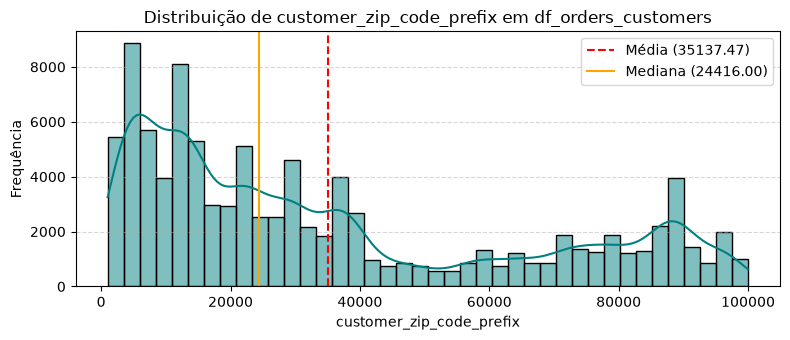

,Coluna,Média,Mediana,Skewness,Kurtosis,Classificação,Outliers (IQR),Outliers (Z-Score)
0,customer_zip_code_prefix,35137.47,24416.0,0.78,-0.79,Assimétrica à Direita (Cauda Longa),0 (0.0%),0 (0.0%)



 📊 ANALISANDO DISTRIBUIÇÕES: df_items


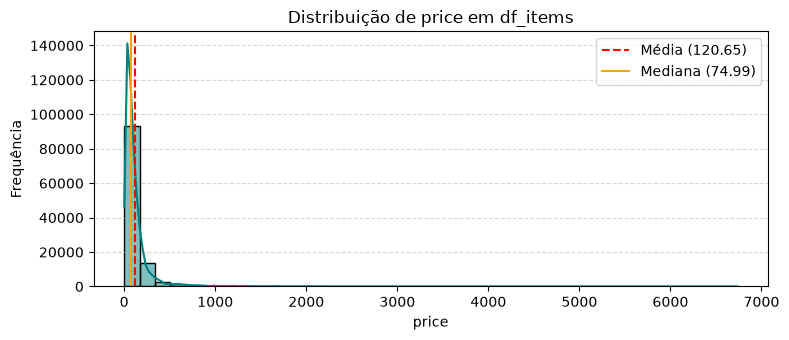

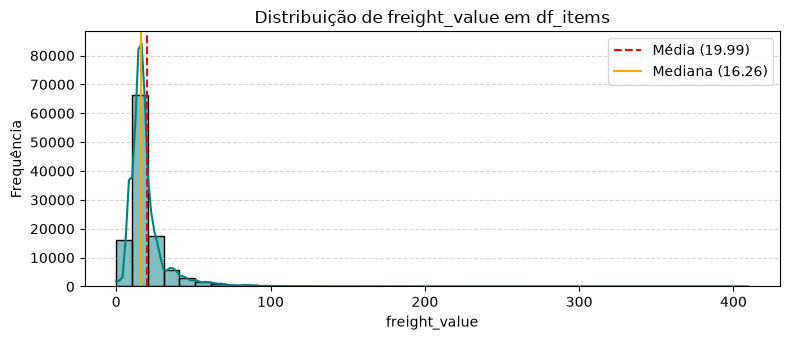

,Coluna,Média,Mediana,Skewness,Kurtosis,Classificação,Outliers (IQR),Outliers (Z-Score)
0,price,120.65,74.99,7.92,120.83,Assimétrica à Direita (Cauda Longa),"8,427 (7.5%)","1,966 (1.7%)"
1,freight_value,19.99,16.26,5.64,59.79,Assimétrica à Direita (Cauda Longa),"12,134 (10.8%)","2,041 (1.8%)"



 📊 ANALISANDO DISTRIBUIÇÕES: df_payments


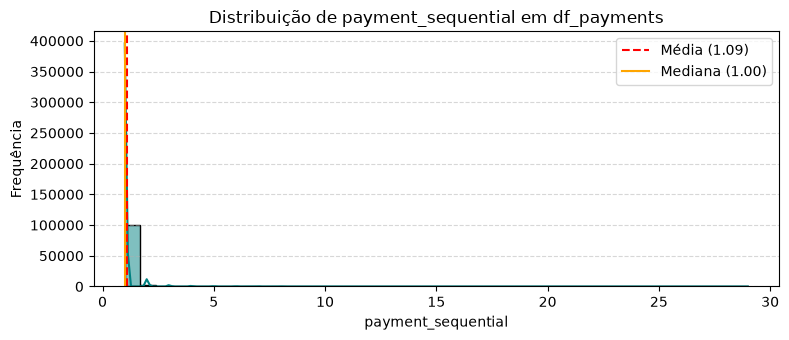

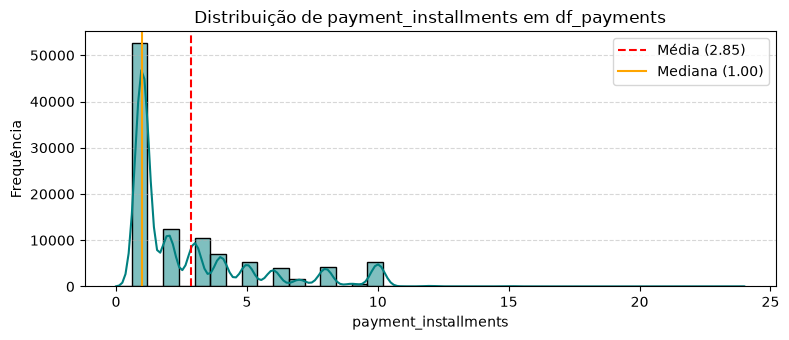

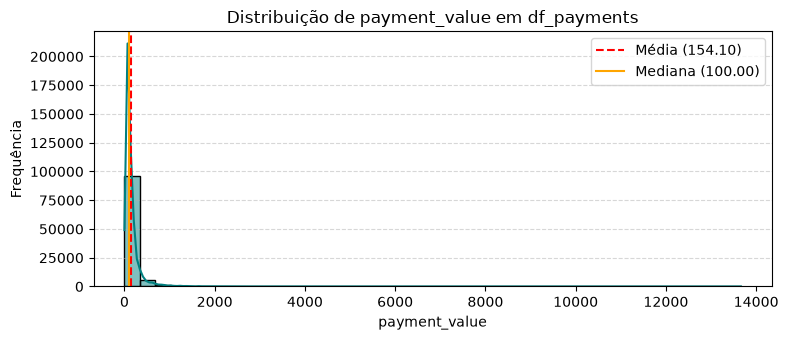

,Coluna,Média,Mediana,Skewness,Kurtosis,Classificação,Outliers (IQR),Outliers (Z-Score)
0,payment_sequential,1.09,1.0,16.18,370.59,Assimétrica à Direita (Cauda Longa),"4,526 (4.4%)",906 (0.9%)
1,payment_installments,2.85,1.0,1.66,2.55,Assimétrica à Direita (Cauda Longa),"6,313 (6.1%)",341 (0.3%)
2,payment_value,154.10,100.0,9.25,241.83,Assimétrica à Direita (Cauda Longa),"7,981 (7.7%)","1,803 (1.7%)"



 📊 ANALISANDO DISTRIBUIÇÕES: df_entrega


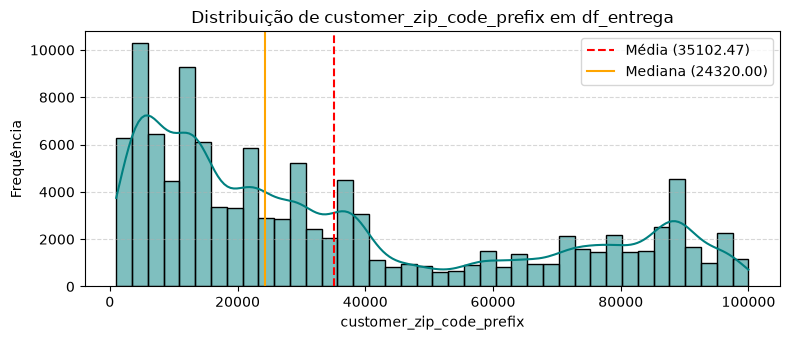

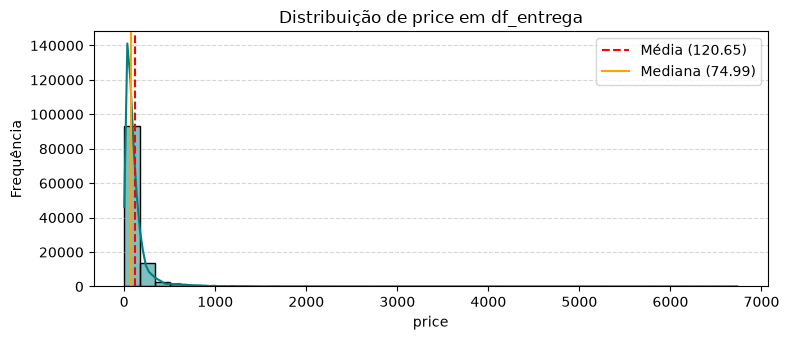

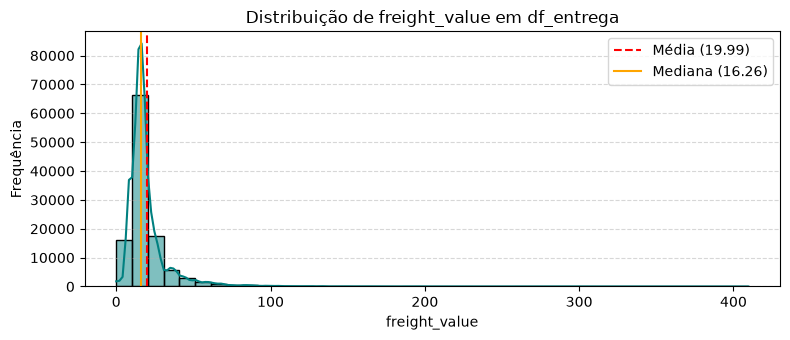

,Coluna,Média,Mediana,Skewness,Kurtosis,Classificação,Outliers (IQR),Outliers (Z-Score)
0,customer_zip_code_prefix,35102.47,24320.00,0.78,-0.79,Assimétrica à Direita (Cauda Longa),0 (0.0%),0 (0.0%)
1,price,120.65,74.99,7.92,120.83,Assimétrica à Direita (Cauda Longa),"8,427 (7.5%)","1,966 (1.7%)"
2,freight_value,19.99,16.26,5.64,59.79,Assimétrica à Direita (Cauda Longa),"12,134 (10.8%)","2,041 (1.8%)"


In [27]:
# # ==============================================================================
# 3.7. Análise de Distribuição e Outliers das Variáveis Quantitativas
# Métodos: Skewness, Kurtosis, IQR, Z-Score (NumPy) e Histogramas
# ==============================================================================

# Dicionário com os DataFrames principais mapeados pelo grupo
dataframes_projeto = {
    'df_orders_customers': df_orders_customers,
    'df_items': df_items,
    'df_payments': df_payments,
    'df_entrega': df_entrega
}

for nome_df, df_atual in dataframes_projeto.items():
    print(f"\n==================================================================")
    print(f" 📊 ANALISANDO DISTRIBUIÇÕES: {nome_df}")
    print(f"==================================================================")
    
    # Seleção das colunas numéricas (excluindo IDs sequenciais/códigos)
    colunas_numericas = df_atual.select_dtypes(include=["number"]).columns
    colunas_numericas = [c for c in colunas_numericas if not c.endswith('_id') and c != 'order_item_id']
    
    if len(colunas_numericas) == 0:
        print(f"Nenhuma coluna numérica contínua encontrada em {nome_df}.\n")
        continue

    dados_distribuicao = []

    for col in colunas_numericas:
        dados = df_atual[col].dropna()
        
        # 1. Cálculo de Assimetria (Skewness) e Curtose (Kurtosis)
        skew = dados.skew()
        kurt = dados.kurt()
        
        # Classificação baseada no Skewness
        if abs(skew) < 0.5:
            tipo_distribuicao = "Aproximadamente Normal"
        elif skew >= 0.5:
            tipo_distribuicao = "Assimétrica à Direita (Cauda Longa)"
        else:
            tipo_distribuicao = "Assimétrica à Esquerda"

        # 2. Cálculo do IQR
        q1 = dados.quantile(0.25)
        q3 = dados.quantile(0.75)
        iqr = q3 - q1
        outliers_iqr = ((dados < (q1 - 1.5 * iqr)) | (dados > (q3 + 1.5 * iqr))).sum()
        pct_iqr = (outliers_iqr / len(dados)) * 100

        # 3. Cálculo do Z-Score com NumPy
        vetor_dados = dados.values
        media_np = np.mean(vetor_dados)
        desvio_np = np.std(vetor_dados)
        outliers_z = np.sum(np.abs((vetor_dados - media_np) / desvio_np) > 3) if desvio_np > 0 else 0
        pct_z = (outliers_z / len(dados)) * 100

        # Armazena os resultados para exibição tabular
        dados_distribuicao.append({
            'Coluna': col,
            'Média': round(media_np, 2),
            'Mediana': round(dados.median(), 2),
            'Skewness': round(skew, 2),
            'Kurtosis': round(kurt, 2),
            'Classificação': tipo_distribuicao,
            'Outliers (IQR)': f"{outliers_iqr:,} ({pct_iqr:.1f}%)",
            'Outliers (Z-Score)': f"{outliers_z:,} ({pct_z:.1f}%)"
        })

        # 4. Histograma da Distribuição
        plt.figure(figsize=(8, 3.5))
        sns.histplot(dados, bins=40, kde=True, color='teal')
        plt.axvline(media_np, color='red', linestyle='--', linewidth=1.5, label=f'Média ({media_np:.2f})')
        plt.axvline(dados.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Mediana ({dados.median():.2f})')
        plt.title(f'Distribuição de {col} em {nome_df}')
        plt.xlabel(col)
        plt.ylabel('Frequência')
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    # Exibe a tabela com o resumo de assimetria e curtose para o DataFrame atual
    df_resumo = pd.DataFrame(dados_distribuicao)
    display(df_resumo)


📊 Gerando histogramas para: df_orders_customers


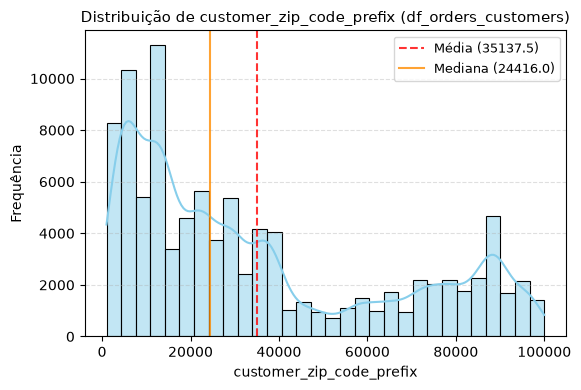


📊 Gerando histogramas para: df_items


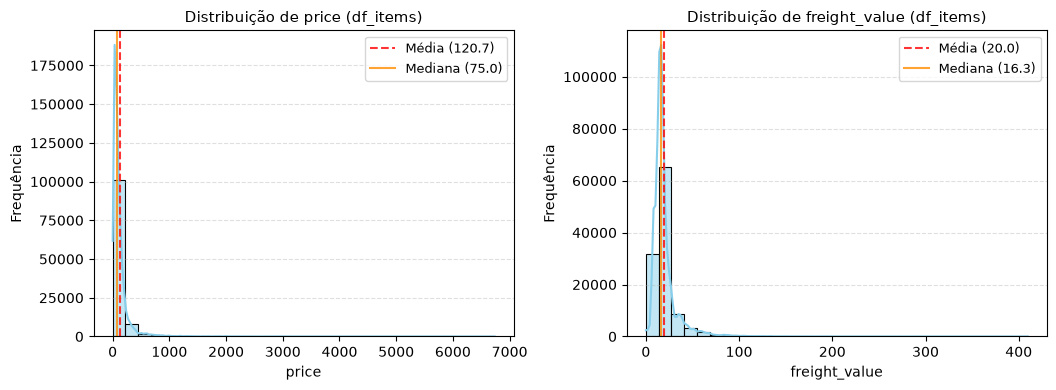


📊 Gerando histogramas para: df_payments


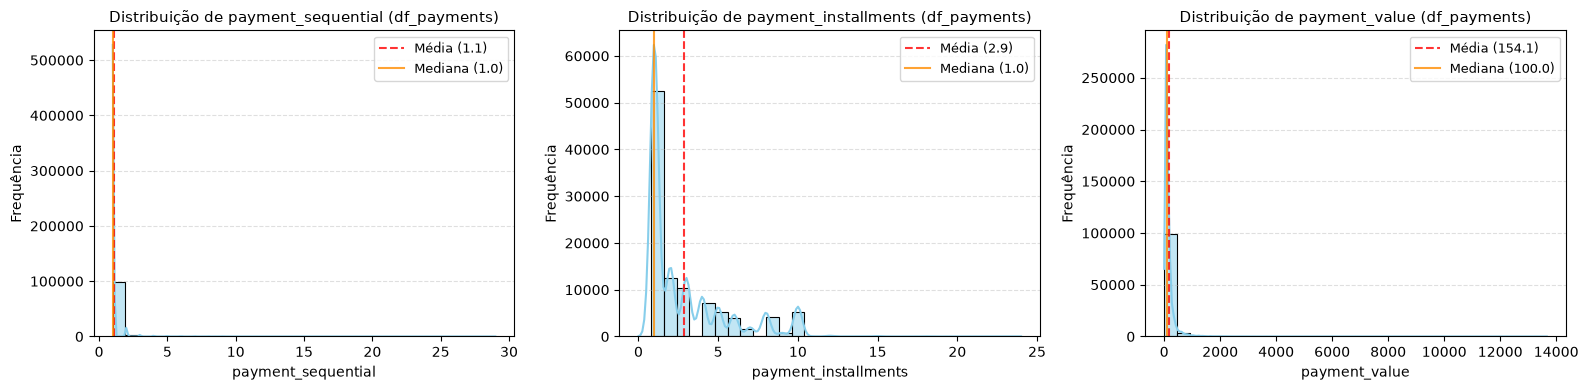


📊 Gerando histogramas para: df_entrega


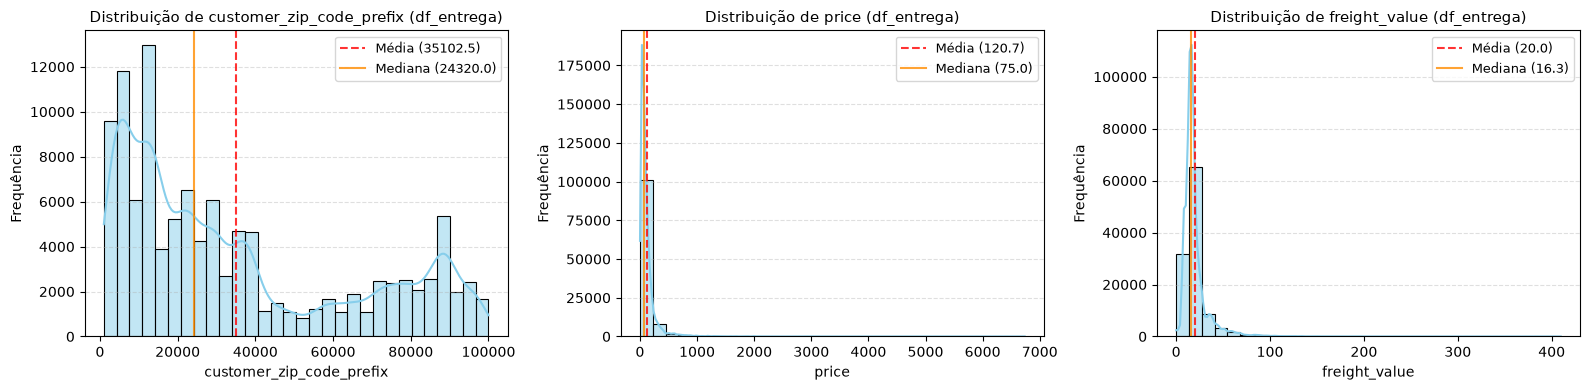

In [29]:
# ==============================================================================
# Plot dos histogramas com estimativa de densidade de kernel (KDE)
# Automatizado para todos os DataFrames do projeto
# ==============================================================================

# Dicionário com os DataFrames mapeados pelo grupo
dataframes_projeto = {
    'df_orders_customers': df_orders_customers,
    'df_items': df_items,
    'df_payments': df_payments,
    'df_entrega': df_entrega
}

for nome_df, df_atual in dataframes_projeto.items():
    # Seleção de colunas numéricas excluindo IDs e códigos sequenciais
    colunas_numericas = df_atual.select_dtypes(include=["number"]).columns
    colunas_numericas = [c for c in colunas_numericas if not c.endswith('_id') and c != 'order_item_id']
    
    if len(colunas_numericas) == 0:
        continue

    print(f"\n📊 Gerando histogramas para: {nome_df}")

    num_cols = len(colunas_numericas)
    cols_per_row = 3
    rows = (num_cols + cols_per_row - 1) // cols_per_row

    plt.figure(figsize=(16, 4 * rows))

    for i, col in enumerate(colunas_numericas, 1):
        plt.subplot(rows, cols_per_row, i)
        
        # Histograma com estimativa de densidade de kernel (KDE)
        sns.histplot(df_atual[col].dropna(), kde=True, bins=30, color='skyblue')
        
        # Linhas de referência para Média e Mediana
        media_val = df_atual[col].mean()
        mediana_val = df_atual[col].median()
        
        plt.axvline(media_val, color='red', linestyle='--', alpha=0.8, label=f'Média ({media_val:.1f})')
        plt.axvline(mediana_val, color='darkorange', linestyle='-', alpha=0.8, label=f'Mediana ({mediana_val:.1f})')
        
        plt.title(f'Distribuição de {col} ({nome_df})', fontsize=11)
        plt.xlabel(col)
        plt.ylabel('Frequência')
        plt.legend(fontsize=9)
        plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

## 4. Limpeza e Transformação

In [31]:
# ==============================================================================
# 1. Lista de todas as colunas com tipos de dados e contagem de não-nulos
# Automatizado para todos os DataFrames do projeto
# ==============================================================================

for nome_df, df_atual in dataframes_projeto.items():
    print(f"\n==================================================================")
    print(f"--- INFORMAÇÕES DO DATASET: {nome_df} ---")
    print(f"==================================================================")
    
    # Exibe informações detalhadas de cada DataFrame
    df_atual.info(verbose=True, show_counts=True)


--- INFORMAÇÕES DO DATASET: df_orders_customers ---
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
 8   customer_unique_id             99441 non-null  str  
 9   customer_zip_code_prefix       99441 non-null  int64
 10  customer_city                  99441 non-null  str  
 11  customer_state                 99441 non-null  str  
dtypes: int64(1), str(11)
memory usag

In [32]:
# ==============================================================================
# 2. Amostra de 5 linhas com todas as colunas visíveis
# Automatizado para todos os DataFrames do projeto
# ==============================================================================

# Configura o Pandas para exibir todas as colunas sem omissão
pd.set_option('display.max_columns', None)

for nome_df, df_atual in dataframes_projeto.items():
    print(f"\n==================================================================")
    print(f"--- AMOSTRA DE 5 LINHAS: {nome_df} ---")
    print(f"==================================================================")
    
    # Exibe as primeiras 5 linhas de cada DataFrame
    display(df_atual.head(5))


--- AMOSTRA DE 5 LINHAS: df_orders_customers ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP



--- AMOSTRA DE 5 LINHAS: df_items ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



--- AMOSTRA DE 5 LINHAS: df_payments ---


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



--- AMOSTRA DE 5 LINHAS: df_entrega ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [34]:
# 0. Definição inicial do DataFrame (aponta para a base tratada de entregas)
df = df_entrega.copy()

# 1. Seleção das colunas essenciais para as Perguntas de Negócio
colunas_essenciais = [
    'order_id',
    'customer_unique_id',
    'customer_state',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'price',
    'freight_value',
    'payment_type',
    'payment_installments',
    'payment_value',
    'product_category_name',
    'product_category_name_english',
    'review_score'
]

# Mantém apenas as colunas que realmente existem no DataFrame
colunas_existentes = [col for col in colunas_essenciais if col in df.columns]
df = df[colunas_existentes].copy()

# 2. Conversão das colunas de data para datetime
colunas_datas = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in colunas_datas:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# 3. Criação de Métricas de Entrega
if 'order_delivered_customer_date' in df.columns and 'order_purchase_timestamp' in df.columns:
    df['tempo_entrega_dias'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

if 'order_delivered_customer_date' in df.columns and 'order_estimated_delivery_date' in df.columns:
    df['dias_diferenca_estimada'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.total_seconds() / (24 * 3600)
    df['entregue_com_atraso'] = df['dias_diferenca_estimada'] > 0

# 4. Preenchimento simples de nulos em categorias
if 'product_category_name' in df.columns:
    df['product_category_name'] = df['product_category_name'].fillna('outro')

if 'product_category_name_english' in df.columns:
    df['product_category_name_english'] = df['product_category_name_english'].fillna('other')

print("--- DATASET REDUZIDO E LIMPO ---")
print(f"Estrutura final: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
display(df.head(3))

--- DATASET REDUZIDO E LIMPO ---
Estrutura final: 113,425 linhas x 11 colunas


,order_id,customer_unique_id,customer_state,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,tempo_entrega_dias,dias_diferenca_estimada,entregue_com_atraso
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,29.99,8.72,8.436574,-7.107488,False
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,118.70,22.76,13.782037,-5.355729,False
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,159.90,19.22,9.394213,-17.245498,False


## 5. Análise Exploratória

--- Top 5 Estados com Maior Proporção de Outliers de Frete/Preço ---
   customer_state  total_itens  qtd_outliers  percentual_outliers  \
0              AC           92            11                11.96   
26             TO          316            29                 9.18   
20             RO          284            21                 7.39   
16             PI          544            40                 7.35   
19             RN          532            39                 7.33   

    mediana_prop_frete  frete_medio  
0             0.348436    40.073370  
26            0.364304    37.246603  
20            0.398336    41.069712  
16            0.332942    39.147970  
19            0.320000    35.652363  


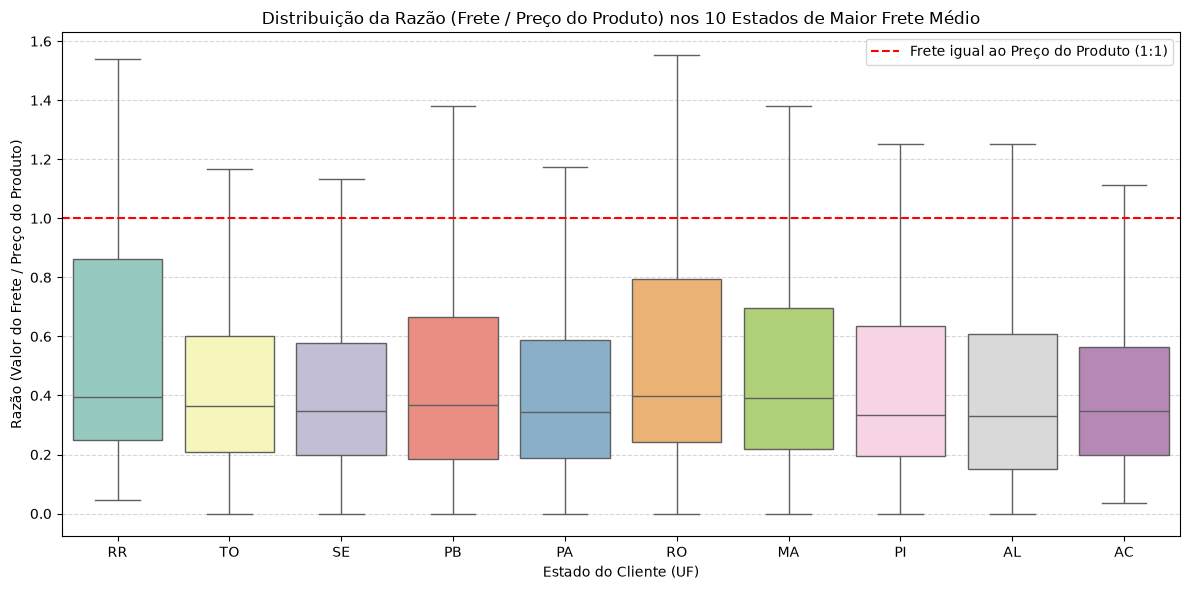

In [37]:
# ==============================================================================
# PERGUNTA 3: Outliers de Valor de Frete em Relação ao Preço das Mercadorias
# Objetivo: Identificar quais estados apresentam os maiores outliers na razão Frete/Preço
# ==============================================================================

# 0. Garante a atribuição do DataFrame consolidado de entregas
df = df_entrega

# 1. Criação da métrica derivada: Razão entre Valor do Frete e Preço do Produto
df['prop_frete_preco'] = df['freight_value'] / df['price']

# 2. Identificação de Outliers usando o método IQR por GRUPO DE COMPARAÇÃO (Estado)
def detecta_outlier_iqr_grupo(df_in, col_valor, col_grupo):
    # Calcula os quartis Q1 e Q3 dentro de cada estado
    q1 = df_in.groupby(col_grupo)[col_valor].transform(lambda x: x.quantile(0.25))
    q3 = df_in.groupby(col_grupo)[col_valor].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1
    
    limite_superior = q3 + (1.5 * iqr)
    limite_inferior = q1 - (1.5 * iqr)
    
    return (df_in[col_valor] > limite_superior) | (df_in[col_valor] < limite_inferior)

# Aplica a detecção de outliers agrupada por estado do cliente
df['is_outlier_frete_estado'] = detecta_outlier_iqr_grupo(df, 'prop_frete_preco', 'customer_state')

# 3. Tabela agregada com métricas numéricas por estado
df_outliers_estado = df.groupby('customer_state').agg(
    total_itens=('order_id', 'count'),
    qtd_outliers=('is_outlier_frete_estado', 'sum'),
    percentual_outliers=('is_outlier_frete_estado', lambda x: round((x.sum() / x.count()) * 100, 2)),
    mediana_prop_frete=('prop_frete_preco', 'median'),
    frete_medio=('freight_value', 'mean')
).reset_index().sort_values(by='percentual_outliers', ascending=False)

print("--- Top 5 Estados com Maior Proporção de Outliers de Frete/Preço ---")
print(df_outliers_estado.head(5))

# 4. Gráfico: Boxplot nos 10 estados com maiores valores de frete médio
top_10_estados_frete = df_outliers_estado.sort_values(by='frete_medio', ascending=False)['customer_state'].head(10)
df_top10 = df[df['customer_state'].isin(top_10_estados_frete)]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_top10, 
    x='customer_state', 
    y='prop_frete_preco', 
    hue='customer_state',    # Ajuste para corrigir o FutureWarning
    palette='Set3',
    legend=False,            # Oculta a legenda do hue para manter o gráfico limpo
    showfliers=False         # Oculta pontos visuais no gráfico para focar nas caixas
)
plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Frete igual ao Preço do Produto (1:1)')
plt.title('Distribuição da Razão (Frete / Preço do Produto) nos 10 Estados de Maior Frete Médio')
plt.xlabel('Estado do Cliente (UF)')
plt.ylabel('Razão (Valor do Frete / Preço do Produto)')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Resposta da Pergunta 3:

Disparidade Geográfica de Outliers: A aplicação do método de limite interquartil (IQR) calculado dentro de cada estado revelou que os estados do Acre (AC - 11,96%), Tocantins (TO - 9,18%), Rondônia (RO - 7,39%), Piauí (PI - 7,35%) e Rio Grande do Norte (RN - 7,33%) lideram a proporção de pedidos cujos custos de frete representam desvios atípicos em relação ao preço cobrado pela mercadoria.

Custo do Frete vs. Valor do Item: O frete médio nesses estados varia de R$ 35,65 (RN) até R$ 41,07 (RO). A mediana da razão frete/preço se situa entre 0,32 e 0,40, o que significa que, para metade das compras efetuadas nesses locais, o custo de envio equivale a pelo menos 32% a 40% do valor do próprio produto.

Casos Extremos (Frete > Produto): O gráfico do boxplot evidencia que, nas regiões Norte e Nordeste (especialmente em RR e RO), a cauda superior da distribuição ultrapassa a linha crítica de 1.0 (linha vermelha pontilhada). Isso indica que há uma quantidade significativa de pedidos onde o comprador paga mais caro no frete do que no próprio produto adquirido.

Recomendações e Impacto para o Negócio
Gargalo Logístico Regional: Os fretes atipicamente altos representam uma barreira crítica de conversão e abandono de carrinho para clientes fora das regiões Sul e Sudeste.
Subsídio de Frete Direcionado: Recomenda-se criar políticas de teto máximo de frete proporcional ou subsídio de frete para produtos de menor ticket médio destinados às regiões Norte e Nordeste, evitando que a taxa de entrega inviabilize a compra.

## 6. Conclusões

# 6. Conclusões e Recomendações Estratégicas

## 6.1. Principais Achados de Negócio

1. **Abismo Logístico Regional (Pergunta 3):**
   * Os estados do Norte e Nordeste (como AC, TO, RO, PI e RN) sofrem com fretes desproporcionalmente altos. Em estados como o Acre, quase **12% das vendas representam custos atípicos de entrega**.
   * Em cerca de 50% dos pedidos nessas regiões, o valor pago pelo envio equivale a pelo menos **32% a 40% do valor da mercadoria**, chegando a ultrapassar a razão 1:1 (frete mais caro que o produto em casos extremos no Amapá e Roraima). Isso aponta para um gargalo de conversão e alto índice de abandono de carrinho nessas regiões.

2. **Gargalo Logístico vs. Satisfação:**
   * Prazos de entrega para o Norte/Nordeste frequentemente superam 20 a 25 dias, correlacionando-se diretamente com menores notas de avaliação e maior taxa de atrasos em relação à data estimada.

3. **Alavancagem de Ticket Médio por Meio de Pagamento:**
   * O Cartão de Crédito é o principal motor do aumento do ticket médio, impulsionado pelo parcelamento. Compras à vista (como Boleto ou Cartão de Débito) apresentam tickets médios significativamente menores.

4. **Concentração de Clientes Pontuais:**
   * A grande maioria dos clientes realiza apenas uma compra na plataforma. Embora o ticket médio por pedido de clientes recorrentes seja ligeiramente superior, a taxa de retenção atual representa uma grande oportunidade não explorada.

---

## 6.2. Limitações da Análise

* **Ausência de Dados de Estoque e Origem:** A base não fornece a localização exata do centro de distribuição (*fulfillment*) ou do vendedor para cada item, impossibilitando calcular a distância exata percorrida em quilômetros.
* **Falta de Dados de Abandono de Carrinho:** Analisou-se apenas os pedidos efetivamente realizados (`orders`), não sendo possível medir exatamente quantas vendas foram perdidas no *checkout* devido ao valor elevado do frete.
* **Correlação vs. Causalidade:** A relação entre o alto custo do frete e o tempo de entrega é de **correlação geográfica/estrutural**, não devendo ser interpretada como falha exclusiva da plataforma, mas sim da infraestrutura logística nacional.

---

## 6.3. Próximos Passos e Recomendações

1. **Política de Subsídio Logístico Regionalizado:** Implementar uma estratégia de teto máximo de frete proporcional para produtos de baixo ticket médio destinados às regiões Norte e Nordeste.
2. **Parcerias com Transportadoras Locais (Centros Avançados):** Avaliar a criação de polos de distribuição regionais no Nordeste para reduzir o tempo de trânsito e o custo do frete fracionado.
3. **Programa de Fidelidade e Reengajamento:** Criar incentivos de *cashback* ou frete grátis na segunda compra para converter clientes pontuais em clientes recorrentes, aumentando o *Lifetime Value* (LTV).
4. **Modelagem Preditiva Futuridade:** Desenvolver um modelo de machine learning (ex: *Clusterização RFM* ou regressão para previsão de churn) para prever quais perfis de clientes têm maior propensão a abandonar a plataforma após a primeira compra.